In [13]:
# =========================================================
# AR5 專用：2004–2024 模式 vs 觀測 驗證流程（完整重整版）
# =========================================================

from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# =========================================================
# 0. 基本設定
# =========================================================
POI_LAT = 25.0190099143756
POI_LON = 121.53137177116402

START_YEAR = 2004
END_YEAR = 2024

# AR5: 2004–2005 用 historical；2006 起用 RCP
SPLIT_YEAR = 2005

TARGET_RCPS =["rcp26", "rcp45", "rcp60", "rcp85"]   # 需要的話可改成 ["rcp26", "rcp45", "rcp60", "rcp85"]

# 已知 360-day 模式
MODELS_360_DAY = {"HadGEM2-ES", "HadGEM2-CC", "HadGEM2-AO"}

# 後續 clean 用的門檻
MIN_COMMON_DAYS = 7500
MIN_SOURCE_FILES = 21

obs_dirs = {
    "tmean": Path(r"C:/觀測_日資料_臺北市_平均溫"),
    "tmax":  Path(r"C:/觀測_日資料_臺北市_最高溫"),
    "tmin":  Path(r"C:/觀測_日資料_臺北市_最低溫"),
}

model_dirs = {
    "tmean": Path(r"C:/AR5_統計降尺度_日資料_臺北市_平均溫"),
    "tmax":  Path(r"C:/AR5_統計降尺度_日資料_臺北市_最高溫"),
    "tmin":  Path(r"C:/AR5_統計降尺度_日資料_臺北市_最低溫"),
}


# =========================================================
# 1. 基本工具
# =========================================================
def read_csv_flexible(csv_path: Path) -> pd.DataFrame:
    df = pd.read_csv(csv_path, encoding="utf-8-sig")

    if len(df.columns) == 1:
        df = pd.read_csv(csv_path, encoding="utf-8-sig", sep=None, engine="python")

    df.columns = [
        str(c).strip().replace("\ufeff", "").replace("'", "").replace('"', "")
        for c in df.columns
    ]
    return df


def remove_unnamed_columns(df: pd.DataFrame) -> pd.DataFrame:
    return df.loc[:, ~df.columns.astype(str).str.contains(r"^Unnamed")].copy()


def ensure_lat_lon(df: pd.DataFrame) -> pd.DataFrame:
    if "LON" not in df.columns or "LAT" not in df.columns:
        raise KeyError(f"缺少 LON/LAT 欄位，實際欄位為：{df.columns.tolist()[:20]}")
    return df


def get_date_columns(columns, start_year=None, end_year=None):
    out = []
    for c in columns:
        c = str(c)
        if re.fullmatch(r"\d{8}", c):
            y = int(c[:4])
            if start_year is not None and y < start_year:
                continue
            if end_year is not None and y > end_year:
                continue
            out.append(c)
    return sorted(out)


def to_datetime_index(idx):
    return pd.to_datetime(pd.Index(idx).astype(str), format="%Y%m%d", errors="coerce")


def find_nearest_row(df: pd.DataFrame, target_lat: float, target_lon: float):
    df = ensure_lat_lon(df)
    dist2 = (df["LAT"] - target_lat) ** 2 + (df["LON"] - target_lon) ** 2
    idx = dist2.idxmin()
    return df.loc[idx].copy()


def estimate_grid_spacing(df: pd.DataFrame, target_lat: float, target_lon: float):
    df = ensure_lat_lon(df)

    nearest = find_nearest_row(df, target_lat, target_lon)
    lat0 = float(nearest["LAT"])
    lon0 = float(nearest["LON"])

    unique_lats = np.sort(df["LAT"].dropna().unique())
    unique_lons = np.sort(df["LON"].dropna().unique())

    lat_neighbors = unique_lats[np.abs(unique_lats - lat0) > 0]
    lon_neighbors = unique_lons[np.abs(unique_lons - lon0) > 0]

    dlat = float(np.min(np.abs(lat_neighbors - lat0))) if len(lat_neighbors) else 0.05
    dlon = float(np.min(np.abs(lon_neighbors - lon0))) if len(lon_neighbors) else 0.05

    return lat0, lon0, dlat, dlon


def calc_coverage_ratio(dt_index, start_year=2004, end_year=2024):
    full_range = pd.date_range(f"{start_year}-01-01", f"{end_year}-12-31", freq="D")
    return len(dt_index) / len(full_range) if len(full_range) else 0.0


def is_series_continuous(dt_index):
    if len(dt_index) == 0:
        return False
    idx = pd.DatetimeIndex(dt_index).sort_values()
    expected = pd.date_range(idx.min(), idx.max(), freq="D")
    return len(idx) == len(expected) and idx.equals(expected)


def validate_common_period(common_index, start_year=2004, end_year=2024):
    coverage = calc_coverage_ratio(common_index, start_year, end_year)
    continuous = is_series_continuous(common_index)
    return {
        "coverage": coverage,
        "continuous": continuous,
        "n_common_days": len(common_index)
    }


# =========================================================
# 2. AR5 檔名解析
# =========================================================
def parse_model_filename(file_path: Path):
    file_name = file_path.name

    pattern = (
        r"^AR5_統計降尺度_日資料_"
        r"(?P<region>.+?)_"
        r"(?P<variable>最高溫|平均溫|最低溫|降雨量)_"
        r"(?P<scenario>historical|rcp26|rcp45|rcp60|rcp85)_"
        r"(?P<model>.+?)_"
        r"(?P<year>\d{4})\.csv$"
    )

    m = re.match(pattern, file_name)
    if not m:
        return None

    info = m.groupdict()
    info["year"] = int(info["year"])
    info["path"] = file_path
    info["stem"] = file_path.stem
    return info


def parse_obs_filename(file_path: Path):
    stem = file_path.stem
    matches = re.findall(r"(?:19|20)\d{2}", stem)
    return int(matches[-1]) if matches else None


# =========================================================
# 3. 建立檔案索引
# =========================================================
def build_model_file_index(var_dir: Path, start_year=2004, end_year=2024, verbose=True):
    rows = []
    failed = []

    for fp in var_dir.glob("*.csv"):
        parsed = parse_model_filename(fp)
        if parsed is None:
            failed.append(fp.name)
            continue

        if start_year <= parsed["year"] <= end_year:
            rows.append(parsed)

    if not rows:
        if verbose:
            print(f"[WARN] 在 {var_dir} 找不到符合格式的 CSV 檔案")
            if failed:
                print("[DEBUG] 前 20 個解析失敗檔名：")
                for x in failed[:20]:
                    print("  ", x)
        return pd.DataFrame(columns=["region", "variable", "scenario", "model", "year", "path", "stem"])

    df = (
        pd.DataFrame(rows)
        .sort_values(["model", "scenario", "year"])
        .drop_duplicates(subset=["model", "scenario", "year"], keep="first")
        .reset_index(drop=True)
    )

    if verbose:
        print(f"[INFO] build_model_file_index: {len(df)} files indexed")
        print(df[["model", "scenario", "year", "stem"]].head(20).to_string(index=False))

    return df


##def build_obs_file_index(obs_dir: Path, start_year=2004, end_year=2024):
   # rows = []

  #  for f in obs_dir.rglob("*.csv"):
     #   year = parse_obs_filename(f)
     #   if year is None:
     #       continue

     #   if start_year <= year <= end_year:
    #        rows.append({"year": year, "path": f})

  #  if not rows:
    #    return pd.DataFrame(columns=["year", "path"])

 #   return (
  #     pd.DataFrame(rows)
      #  .sort_values("year")
      # .drop_duplicates("year")
  #      .reset_index(drop=True)
 #   )

def build_obs_file_index(obs_dir: Path, start_year=2004, end_year=2024):
    """
    只抓真正的觀測主檔：
    - 觀測_日資料_臺北市_平均溫_YYYY.csv
    - 觀測_日資料_臺北市_最高溫_YYYY.csv
    - 觀測_日資料_臺北市_最低溫_YYYY.csv

    排除：
    - 參考測站平均距離
    - 參考測站溫度標準差
    """
    rows = []

    obs_dir_name = obs_dir.name
    if "平均溫" in obs_dir_name:
        variable_label = "平均溫"
    elif "最高溫" in obs_dir_name:
        variable_label = "最高溫"
    elif "最低溫" in obs_dir_name:
        variable_label = "最低溫"
    else:
        variable_label = None

    for f in sorted(obs_dir.glob("*.csv")):
        fname = f.name

        # 排除附屬檔
        if "參考測站平均距離" in fname:
            continue
        if "參考測站溫度標準差" in fname:
            continue

        # 若能判斷變數，則只保留主檔
        if variable_label is not None and variable_label not in fname:
            continue

        match = re.search(r"(?:19|20)\d{2}", fname)
        if not match:
            continue

        year = int(match.group(0))
        if not (start_year <= year <= end_year):
            continue

        rows.append({
            "year": year,
            "path": f
        })

    if not rows:
        return pd.DataFrame(columns=["year", "path"])

    df = (
        pd.DataFrame(rows)
        .sort_values("year")
        .drop_duplicates(subset=["year"], keep="first")
        .reset_index(drop=True)
    )

    return df

# =========================================================
# 4. 讀單一模式檔：最近格點 daily series
# =========================================================
def read_model_one_file_nearest(csv_path: Path, target_lat, target_lon):
    df = read_csv_flexible(csv_path)
    df = remove_unnamed_columns(df)
    df = ensure_lat_lon(df)

    nearest = find_nearest_row(df, target_lat, target_lon)

    date_cols = get_date_columns(df.columns)
    if not date_cols:
        return pd.Series(dtype=float), None, None

    s = nearest[date_cols].copy()
    s.index = to_datetime_index(s.index)
    s = pd.to_numeric(s, errors="coerce")
    s = s[~s.index.isna()].sort_index()

    model_lat = float(nearest["LAT"])
    model_lon = float(nearest["LON"])

    return s, model_lat, model_lon


# =========================================================
# 5. 讀單一年觀測檔：模式格內高解析格點平均
# =========================================================
def read_obs_one_year_spatial_mean(csv_path, model_lat, model_lon, dlat, dlon):
    df = read_csv_flexible(csv_path)
    df = remove_unnamed_columns(df)
    df = ensure_lat_lon(df)

    date_cols = get_date_columns(df.columns)
    if not date_cols:
        return pd.Series(dtype=float)

    lat_min = model_lat - dlat / 2
    lat_max = model_lat + dlat / 2
    lon_min = model_lon - dlon / 2
    lon_max = model_lon + dlon / 2

    sub = df[
        (df["LAT"] >= lat_min) & (df["LAT"] <= lat_max) &
        (df["LON"] >= lon_min) & (df["LON"] <= lon_max)
    ].copy()

    if sub.empty:
        nearest = find_nearest_row(df, model_lat, model_lon)
        sub = pd.DataFrame([nearest])

    # 對同一天 across grid 做空間平均
    s = sub[date_cols].mean(axis=0)
    s.index = pd.to_datetime(s.index, format="%Y%m%d")
    s = pd.to_numeric(s, errors="coerce")
    s = s.sort_index()

    return s


# =========================================================
# 6. 組裝模式與觀測時間序列
# =========================================================
def load_model_series_from_index(index_df, model_name, rcp, target_lat, target_lon,
                                 start_year=2004, end_year=2024, split_year=2005):
    if index_df.empty:
        return pd.Series(dtype=float), None, None, [], pd.DataFrame()

    inspect_rows = []
    actual_rows = []

    for year in range(start_year, end_year + 1):
        expected_scenario = "historical" if year <= split_year else rcp

        sub = index_df[
            (index_df["model"] == model_name) &
            (index_df["scenario"] == expected_scenario) &
            (index_df["year"] == year)
        ]

        inspect_rows.append({
            "year": year,
            "expected_scenario": expected_scenario,
            "found": not sub.empty,
            "n_files": len(sub),
            "stem": sub.iloc[0]["stem"] if not sub.empty else None
        })

        if not sub.empty:
            actual_rows.append(sub.iloc[0])

    inspect_df = pd.DataFrame(inspect_rows)

    if not actual_rows:
        return pd.Series(dtype=float), None, None, [], inspect_df

    series_list = []
    source_files = []
    chosen_model_lat = None
    chosen_model_lon = None

    for row in actual_rows:
        s, model_lat, model_lon = read_model_one_file_nearest(
            row["path"], target_lat, target_lon
        )

        if s.empty:
            continue

        s = s[s.index.year == row["year"]]
        if s.empty:
            continue

        series_list.append(s)
        source_files.append(row["path"])

        if chosen_model_lat is None:
            chosen_model_lat = model_lat
            chosen_model_lon = model_lon

    if not series_list:
        return pd.Series(dtype=float), None, None, source_files, inspect_df

    out = pd.concat(series_list).sort_index()
    out = out[~out.index.duplicated(keep="first")]

    return out, chosen_model_lat, chosen_model_lon, source_files, inspect_df


def load_obs_series_from_index(obs_index_df, model_lat, model_lon, dlat, dlon,
                               start_year=2004, end_year=2024):
    if obs_index_df.empty:
        return pd.Series(dtype=float)

    series_list = []

    for year in range(start_year, end_year + 1):
        sub = obs_index_df[obs_index_df["year"] == year]
        if sub.empty:
            continue

        f = sub.iloc[0]["path"]
        s = read_obs_one_year_spatial_mean(f, model_lat, model_lon, dlat, dlon)

        if s.empty:
            continue

        s = s[s.index.year == year]
        if not s.empty:
            series_list.append(s)

    if not series_list:
        return pd.Series(dtype=float)

    out = pd.concat(series_list).sort_index()
    out = out[~out.index.duplicated(keep="first")]

    return out


# =========================================================
# 7. 主流程
# =========================================================
def prepare_temperature_data(
    obs_dirs,
    model_dirs,
    variables=("tmean", "tmax", "tmin"),
    target_rcps=("rcp45", "rcp85"),
    target_lat=25.0190099143756,
    target_lon=121.53137177116402,
    start_year=2004,
    end_year=2024,
    split_year=2005
):
    temp_data = {}
    availability_rows = []
    inspect_all = []

    for var in variables:
        print(f"\n==============================")
        print(f"[PROCESS] variable = {var}")
        print(f"==============================")

        var_model_dir = model_dirs[var]
        var_obs_dir = obs_dirs[var]

        print(f"[MODEL DIR] {var_model_dir}")
        print(f"[OBS DIR]   {var_obs_dir}")

        if not var_model_dir.exists():
            print(f"[WARN] model dir not found: {var_model_dir}")
            temp_data[var] = {}
            continue

        if not var_obs_dir.exists():
            print(f"[WARN] obs dir not found: {var_obs_dir}")
            temp_data[var] = {}
            continue

        model_index = build_model_file_index(var_model_dir, start_year, end_year, verbose=True)
        obs_index = build_obs_file_index(var_obs_dir, start_year, end_year)

        print(f"[INFO] model files found: {len(model_index)}")
        print(f"[INFO] obs files found  : {len(obs_index)}")

        if model_index.empty or obs_index.empty:
            temp_data[var] = {}
            continue

        # 手動排除 360-day 模式
        excluded_360_models = sorted(set(model_index["model"].unique()) & MODELS_360_DAY)
        if excluded_360_models:
            print(f"[INFO] manually exclude 360-day models: {excluded_360_models}")
            model_index = model_index[~model_index["model"].isin(excluded_360_models)].copy()
        else:
            print("[INFO] no manual 360-day models found in this variable")

        if model_index.empty:
            temp_data[var] = {}
            continue

        models = sorted(model_index["model"].unique())
        print(f"[INFO] models found: {len(models)}")
        print(models)

        sample_file = model_index.iloc[0]["path"]
        sample_df = read_csv_flexible(sample_file)
        sample_df = remove_unnamed_columns(sample_df)
        sample_df = ensure_lat_lon(sample_df)
        _, _, dlat, dlon = estimate_grid_spacing(sample_df, target_lat, target_lon)
        print(f"[INFO] estimated grid spacing: dlat={dlat:.4f}, dlon={dlon:.4f}")

        temp_data[var] = {}

        for model_name in models:
            temp_data[var][model_name] = {}

            for rcp in target_rcps:
                print(f"\n--- {var} | {model_name} | {rcp} ---")

                model_ts, model_lat, model_lon, source_files, inspect_df = load_model_series_from_index(
                    model_index, model_name, rcp, target_lat, target_lon,
                    start_year, end_year, split_year
                )

                inspect_df["variable"] = var
                inspect_df["model"] = model_name
                inspect_df["rcp"] = rcp
                inspect_all.append(inspect_df)

                if model_ts.empty or model_lat is None:
                    print("[DROP] no model series")
                    availability_rows.append({
                        "variable": var,
                        "model": model_name,
                        "rcp": rcp,
                        "status": "drop_no_model_data",
                        "coverage": np.nan,
                        "continuous": np.nan,
                        "n_common_days": 0,
                        "model_lat": np.nan,
                        "model_lon": np.nan,
                        "n_source_files": len(source_files)
                    })
                    continue

                obs_ts = load_obs_series_from_index(
                    obs_index, model_lat, model_lon, dlat, dlon, start_year, end_year
                )

                if obs_ts.empty:
                    print("[DROP] no obs series")
                    availability_rows.append({
                        "variable": var,
                        "model": model_name,
                        "rcp": rcp,
                        "status": "drop_no_obs_data",
                        "coverage": np.nan,
                        "continuous": np.nan,
                        "n_common_days": 0,
                        "model_lat": model_lat,
                        "model_lon": model_lon,
                        "n_source_files": len(source_files)
                    })
                    continue

                common_index = model_ts.index.intersection(obs_ts.index).sort_values()

                if len(common_index) == 0:
                    print("[DROP] no common dates")
                    availability_rows.append({
                        "variable": var,
                        "model": model_name,
                        "rcp": rcp,
                        "status": "drop_no_common_dates",
                        "coverage": 0.0,
                        "continuous": False,
                        "n_common_days": 0,
                        "model_lat": model_lat,
                        "model_lon": model_lon,
                        "n_source_files": len(source_files)
                    })
                    continue

                model_common = model_ts.loc[common_index]
                obs_common = obs_ts.loc[common_index]

                out_df = pd.DataFrame({
                    "obs": obs_common.values,
                    "model": model_common.values
                }, index=common_index)

                out_df["bias"] = out_df["model"] - out_df["obs"]

                check = validate_common_period(common_index, start_year, end_year)

                temp_data[var][model_name][rcp] = {
                    "model_lat": model_lat,
                    "model_lon": model_lon,
                    "coverage": check["coverage"],
                    "continuous": check["continuous"],
                    "n_common_days": check["n_common_days"],
                    "source_files": source_files,
                    "data": out_df
                }

                print(
                    f"[KEEP] coverage={check['coverage']:.3f}, "
                    f"continuous={check['continuous']}, "
                    f"n={check['n_common_days']}, files={len(source_files)}"
                )

                availability_rows.append({
                    "variable": var,
                    "model": model_name,
                    "rcp": rcp,
                    "status": "keep",
                    "coverage": check["coverage"],
                    "continuous": check["continuous"],
                    "n_common_days": check["n_common_days"],
                    "model_lat": model_lat,
                    "model_lon": model_lon,
                    "n_source_files": len(source_files)
                })

    availability_df = pd.DataFrame(availability_rows)

    if inspect_all:
        inspect_all_df = pd.concat(inspect_all, ignore_index=True)
    else:
        inspect_all_df = pd.DataFrame(columns=["year", "expected_scenario", "found", "n_files", "stem", "variable", "model", "rcp"])

    return temp_data, availability_df, inspect_all_df


# =========================================================
# 8. 執行主流程
# =========================================================
temp_data, availability_df, inspect_all_df = prepare_temperature_data(
    obs_dirs=obs_dirs,
    model_dirs=model_dirs,
    variables=("tmean", "tmax", "tmin"),
    target_rcps=TARGET_RCPS,
    target_lat=POI_LAT,
    target_lon=POI_LON,
    start_year=START_YEAR,
    end_year=END_YEAR,
    split_year=SPLIT_YEAR
)

print("\n===== availability_df =====")
if availability_df.empty:
    print("沒有任何結果，請檢查路徑或檔名格式")
else:
    print(availability_df.sort_values(["variable", "model", "rcp"]).to_string(index=False))

print("\n===== inspect_all_df (head) =====")
if inspect_all_df.empty:
    print("沒有 inspect 結果")
else:
    print(inspect_all_df.head(50).to_string(index=False))


# =========================================================
# 9. 篩選完整組合
# =========================================================
good_availability = availability_df[
    (availability_df["n_common_days"] >= MIN_COMMON_DAYS) &
    (availability_df["n_source_files"] >= MIN_SOURCE_FILES)
].copy()

print(f"\n[INFO] good combinations: {len(good_availability)}")

clean_temp_data = {}

good_keys = set(
    zip(
        good_availability["variable"],
        good_availability["model"],
        good_availability["rcp"]
    )
)

for var, model_dict in temp_data.items():
    clean_temp_data[var] = {}

    for model_name, rcp_dict in model_dict.items():
        kept_rcps = {}

        for rcp, info in rcp_dict.items():
            if (var, model_name, rcp) in good_keys:
                kept_rcps[rcp] = info

        if kept_rcps:
            clean_temp_data[var][model_name] = kept_rcps

print("\n===== clean_temp_data check =====")
for var, model_dict in clean_temp_data.items():
    print(f"\n[{var}]")
    for model_name, rcp_dict in model_dict.items():
        for rcp, info in rcp_dict.items():
            print(
                f"{model_name} {rcp} -> days={info['n_common_days']}, files={len(info['source_files'])}"
            )


# =========================================================
# 10. summary_df
# =========================================================
def calc_metrics(df):
    diff = df["model"] - df["obs"]
    return pd.Series({
        "bias_mean": diff.mean(),
        "mae": diff.abs().mean(),
        "rmse": np.sqrt((diff ** 2).mean()),
        "corr": df["model"].corr(df["obs"]),
        "n_days": len(df)
    })

summary_rows = []

for var, model_dict in clean_temp_data.items():
    for model_name, rcp_dict in model_dict.items():
        for rcp, info in rcp_dict.items():
            df = info["data"]
            if df.empty:
                continue

            met = calc_metrics(df)
            met["variable"] = var
            met["model"] = model_name
            met["rcp"] = rcp
            met["coverage"] = info["coverage"]
            met["continuous"] = info["continuous"]
            summary_rows.append(met)

summary_df = pd.DataFrame(summary_rows)

print("\n===== summary_df =====")
if summary_df.empty:
    print("目前沒有 summary")
else:
    summary_df = summary_df[
        ["variable", "model", "rcp", "bias_mean", "mae", "rmse", "corr", "n_days", "coverage", "continuous"]
    ].sort_values(["variable", "rmse", "corr"], ascending=[True, True, False])
    print(summary_df.to_string(index=False))


# =========================================================
# 11. result_df（後續畫圖與排名直接用這個）
# =========================================================
result_df = summary_df.rename(columns={"bias_mean": "bias"}).copy()

print("\n===== result_df head =====")
if result_df.empty:
    print("目前沒有 result_df")
else:
    print(result_df.head().to_string(index=False))


# =========================================================
# 12. 快速檢查某一組時間序列是否合理
# =========================================================
# 例子：
# example = clean_temp_data["tmean"]["ACCESS1-0"]["rcp45"]["data"]
# print(example.head())
# print(example.describe())
# example[["obs", "model"]].plot(figsize=(12,4), title="ACCESS1-0 rcp45 tmean")
# plt.show()


# =========================================================
# 13. 簡單圖示
# =========================================================
def plot_model_performance(result_df, variable):
    sub = result_df[result_df["variable"] == variable].copy()
    if sub.empty:
        print(f"[WARN] no data for {variable}")
        return

    plt.figure(figsize=(6, 6))
    for rcp in sorted(sub["rcp"].unique()):
        s = sub[sub["rcp"] == rcp]
        plt.scatter(s["rmse"], s["corr"], label=rcp)

        for _, row in s.iterrows():
            plt.text(row["rmse"], row["corr"], row["model"], fontsize=7)

    plt.xlabel("RMSE")
    plt.ylabel("Correlation")
    plt.title(f"{variable} Model Performance")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


# 例子：
# plot_model_performance(result_df, "tmean")
# plot_model_performance(result_df, "tmax")
# plot_model_performance(result_df, "tmin")


[PROCESS] variable = tmean
[MODEL DIR] C:\AR5_統計降尺度_日資料_臺北市_平均溫
[OBS DIR]   C:\觀測_日資料_臺北市_平均溫
[INFO] build_model_file_index: 2006 files indexed
    model   scenario  year                                            stem
ACCESS1-0 historical  2004 AR5_統計降尺度_日資料_臺北市_平均溫_historical_ACCESS1-0_2004
ACCESS1-0 historical  2005 AR5_統計降尺度_日資料_臺北市_平均溫_historical_ACCESS1-0_2005
ACCESS1-0      rcp45  2006      AR5_統計降尺度_日資料_臺北市_平均溫_rcp45_ACCESS1-0_2006
ACCESS1-0      rcp45  2007      AR5_統計降尺度_日資料_臺北市_平均溫_rcp45_ACCESS1-0_2007
ACCESS1-0      rcp45  2008      AR5_統計降尺度_日資料_臺北市_平均溫_rcp45_ACCESS1-0_2008
ACCESS1-0      rcp45  2009      AR5_統計降尺度_日資料_臺北市_平均溫_rcp45_ACCESS1-0_2009
ACCESS1-0      rcp45  2010      AR5_統計降尺度_日資料_臺北市_平均溫_rcp45_ACCESS1-0_2010
ACCESS1-0      rcp45  2011      AR5_統計降尺度_日資料_臺北市_平均溫_rcp45_ACCESS1-0_2011
ACCESS1-0      rcp45  2012      AR5_統計降尺度_日資料_臺北市_平均溫_rcp45_ACCESS1-0_2012
ACCESS1-0      rcp45  2013      AR5_統計降尺度_日資料_臺北市_平均溫_rcp45_ACCESS1-0_2013
ACCESS1-0      rcp45  2014    

In [14]:
obs_index_dict = {
    "tmean": build_obs_index(obs_dirs["tmean"], "平均溫"),
    "tmax":  build_obs_index(obs_dirs["tmax"],  "最高溫"),
    "tmin":  build_obs_index(obs_dirs["tmin"],  "最低溫"),
}

for var, idx in obs_index_dict.items():
    print(f"\n[{var}]")
    print(idx.head())
    print(f"年份數量: {len(idx)}")


[tmean]
   year                                       path
0  1960  C:\觀測_日資料_臺北市_平均溫\觀測_日資料_臺北市_平均溫_1960.csv
1  1961  C:\觀測_日資料_臺北市_平均溫\觀測_日資料_臺北市_平均溫_1961.csv
2  1962  C:\觀測_日資料_臺北市_平均溫\觀測_日資料_臺北市_平均溫_1962.csv
3  1963  C:\觀測_日資料_臺北市_平均溫\觀測_日資料_臺北市_平均溫_1963.csv
4  1964  C:\觀測_日資料_臺北市_平均溫\觀測_日資料_臺北市_平均溫_1964.csv
年份數量: 65

[tmax]
   year                                       path
0  1960  C:\觀測_日資料_臺北市_最高溫\觀測_日資料_臺北市_最高溫_1960.csv
1  1961  C:\觀測_日資料_臺北市_最高溫\觀測_日資料_臺北市_最高溫_1961.csv
2  1962  C:\觀測_日資料_臺北市_最高溫\觀測_日資料_臺北市_最高溫_1962.csv
3  1963  C:\觀測_日資料_臺北市_最高溫\觀測_日資料_臺北市_最高溫_1963.csv
4  1964  C:\觀測_日資料_臺北市_最高溫\觀測_日資料_臺北市_最高溫_1964.csv
年份數量: 65

[tmin]
   year                                       path
0  1960  C:\觀測_日資料_臺北市_最低溫\觀測_日資料_臺北市_最低溫_1960.csv
1  1961  C:\觀測_日資料_臺北市_最低溫\觀測_日資料_臺北市_最低溫_1961.csv
2  1962  C:\觀測_日資料_臺北市_最低溫\觀測_日資料_臺北市_最低溫_1962.csv
3  1963  C:\觀測_日資料_臺北市_最低溫\觀測_日資料_臺北市_最低溫_1963.csv
4  1964  C:\觀測_日資料_臺北市_最低溫\觀測_日資料_臺北市_最低溫_1964.csv
年份數量: 65


In [5]:
obs_index = build_obs_file_index(obs_dirs["tmean"], START_YEAR, END_YEAR)
print(obs_index.head())
print(len(obs_index))

   year                                       path
0  2004  C:\觀測_日資料_臺北市_平均溫\觀測_日資料_臺北市_平均溫_2004.csv
1  2005  C:\觀測_日資料_臺北市_平均溫\觀測_日資料_臺北市_平均溫_2005.csv
2  2006  C:\觀測_日資料_臺北市_平均溫\觀測_日資料_臺北市_平均溫_2006.csv
3  2007  C:\觀測_日資料_臺北市_平均溫\觀測_日資料_臺北市_平均溫_2007.csv
4  2008  C:\觀測_日資料_臺北市_平均溫\觀測_日資料_臺北市_平均溫_2008.csv
21


In [15]:
MIN_COMMON_DAYS = 7600   # 接近 7665
MIN_SOURCE_FILES = 21

good_availability = availability_df[
    (availability_df["n_common_days"] >= MIN_COMMON_DAYS) &
    (availability_df["n_source_files"] == MIN_SOURCE_FILES)
].copy()

In [16]:
clean_temp_data = {}

good_keys = set(
    zip(
        good_availability["variable"],
        good_availability["model"],
        good_availability["rcp"]
    )
)

for var, model_dict in temp_data.items():
    clean_temp_data[var] = {}

    for model_name, rcp_dict in model_dict.items():
        kept_rcps = {}

        for rcp, info in rcp_dict.items():
            if (var, model_name, rcp) in good_keys:
                kept_rcps[rcp] = info

        if kept_rcps:
            clean_temp_data[var][model_name] = kept_rcps

In [8]:
results = []

for var, model_dict in clean_temp_data.items():
    for model_name, rcp_dict in model_dict.items():
        for rcp, info in rcp_dict.items():

            df = info["data"].copy()

            if df.empty or len(df) < 100:
                continue

            bias = (df["model"] - df["obs"]).mean()
            rmse = np.sqrt(((df["model"] - df["obs"]) ** 2).mean())
            corr = df["model"].corr(df["obs"])

            results.append({
                "variable": var,
                "model": model_name,
                "rcp": rcp,
                "bias": bias,
                "rmse": rmse,
                "corr": corr,
                "n_days": len(df),
                "coverage": info["coverage"],
            })

result_df = pd.DataFrame(results)

print(result_df.head())

  variable      model    rcp      bias      rmse      corr  n_days  coverage
0    tmean  ACCESS1-0  rcp45  0.976249  3.747733  0.784126    7665  0.999218
1    tmean  ACCESS1-0  rcp85  0.686399  3.695005  0.787163    7665  0.999218
2    tmean  ACCESS1-3  rcp45  0.186091  3.508832  0.792429    7665  0.999218
3    tmean  ACCESS1-3  rcp85  0.214929  3.468657  0.802561    7665  0.999218
4    tmean    BNU-ESM  rcp45  0.567728  3.631518  0.785443    7665  0.999218


In [17]:
for var in result_df["variable"].unique():
    print(f"\n===== {var} =====")
    sub = result_df[result_df["variable"] == var].sort_values("rmse")
    print(sub.head(10).to_string(index=False))


===== tmax =====
variable          model   rcp     bias      mae     rmse     corr  n_days  coverage  continuous
    tmax   IPSL-CM5A-LR rcp85 0.696028 3.608374 4.714255 0.736637  7665.0  0.999218       False
    tmax   bcc-csm1-1-m rcp45 0.900520 3.632761 4.750021 0.726228  7665.0  0.999218       False
    tmax         MIROC5 rcp26 0.515790 3.641594 4.768304 0.711372  7665.0  0.999218       False
    tmax   IPSL-CM5A-LR rcp60 0.849936 3.617234 4.776967 0.727137  7665.0  0.999218       False
    tmax      ACCESS1-3 rcp85 0.222826 3.684659 4.802911 0.714559  7665.0  0.999218       False
    tmax MIROC-ESM-CHEM rcp85 0.679689 3.687524 4.810631 0.713817  7665.0  0.999218       False
    tmax   IPSL-CM5A-LR rcp26 1.011736 3.677793 4.813254 0.732505  7665.0  0.999218       False
    tmax     CESM1-CAM5 rcp60 0.300517 3.715937 4.813994 0.706842  7665.0  0.999218       False
    tmax      NorESM1-M rcp26 0.885441 3.695667 4.816794 0.714728  7665.0  0.999218       False
    tmax      MIROC-ES

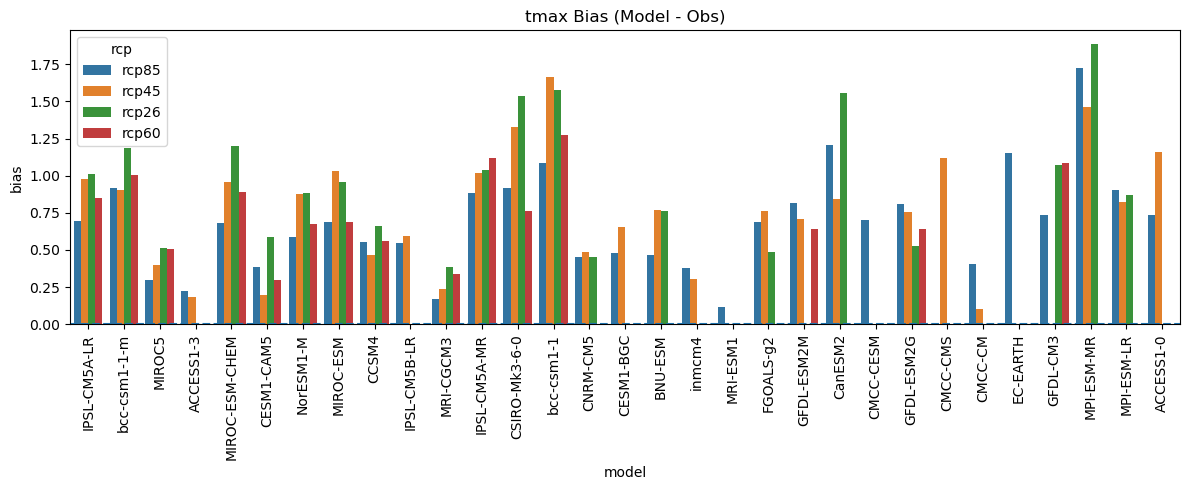

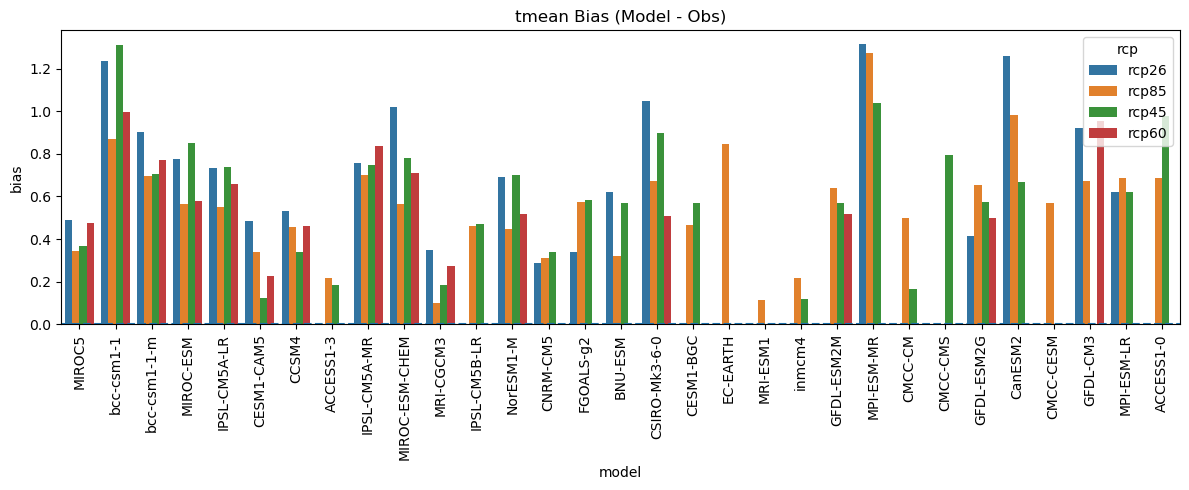

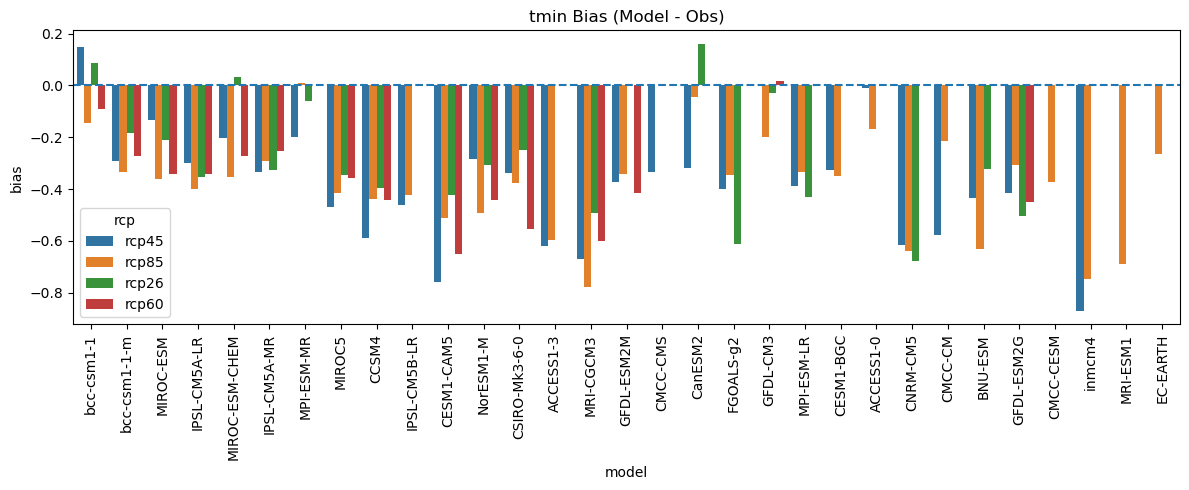

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

for var in result_df["variable"].unique():
    plt.figure(figsize=(12,5))

    sub = result_df[result_df["variable"] == var]

    sns.barplot(data=sub, x="model", y="bias", hue="rcp")

    plt.axhline(0, linestyle="--")
    plt.xticks(rotation=90)
    plt.title(f"{var} Bias (Model - Obs)")
    plt.tight_layout()
    outpath = output_dir /f"{var} Bias (Model - Obs).png"
    plt.savefig(outpath, dpi=300, bbox_inches="tight")
    plt.show()

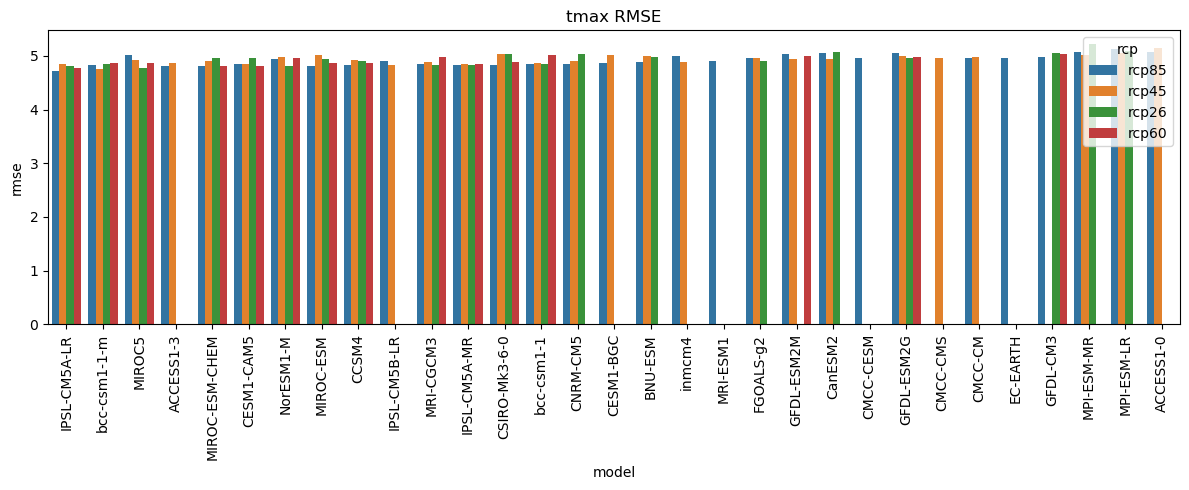

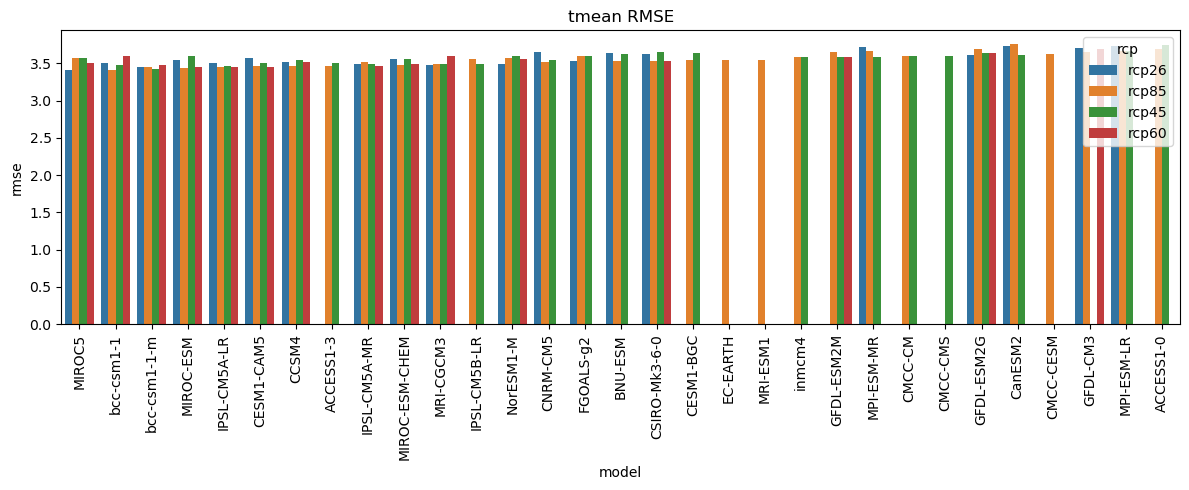

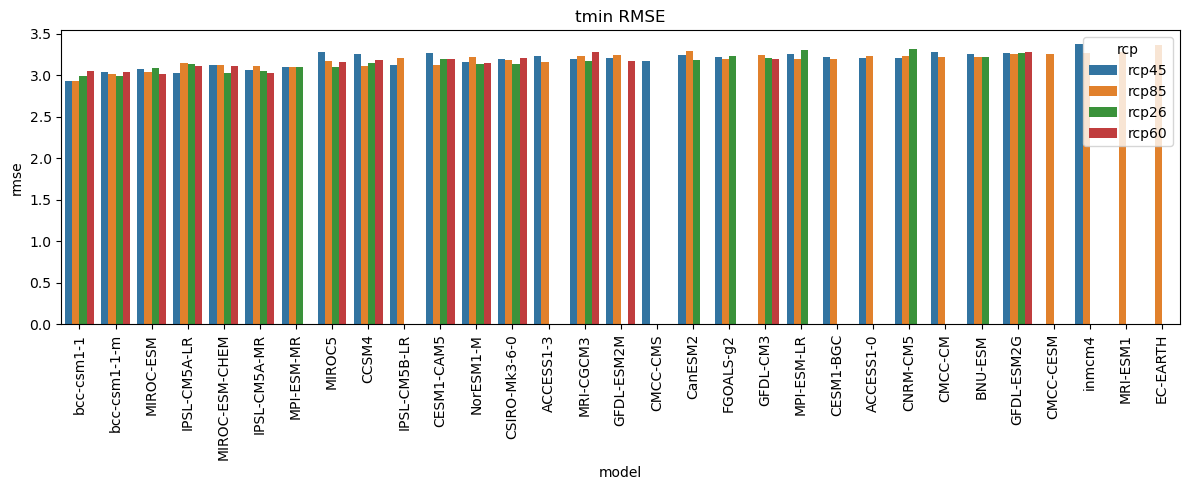

In [22]:
for var in result_df["variable"].unique():
    plt.figure(figsize=(12,5))

    sub = result_df[result_df["variable"] == var]

    sns.barplot(data=sub, x="model", y="rmse", hue="rcp")

    plt.xticks(rotation=90)
    plt.title(f"{var} RMSE")
    plt.tight_layout()
    outpath = output_dir /f"{var} RMS.png"
    plt.savefig(outpath, dpi=300, bbox_inches="tight")
    plt.show()

In [20]:
output_dir= Path(r"C:\Users\user\Climate_project\程式作業\Daxue＿village\figue")
output_dir.mkdir(exist_ok=True)

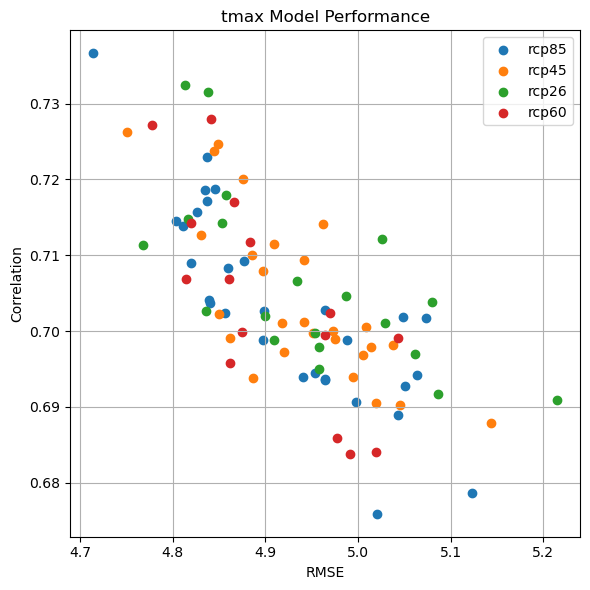

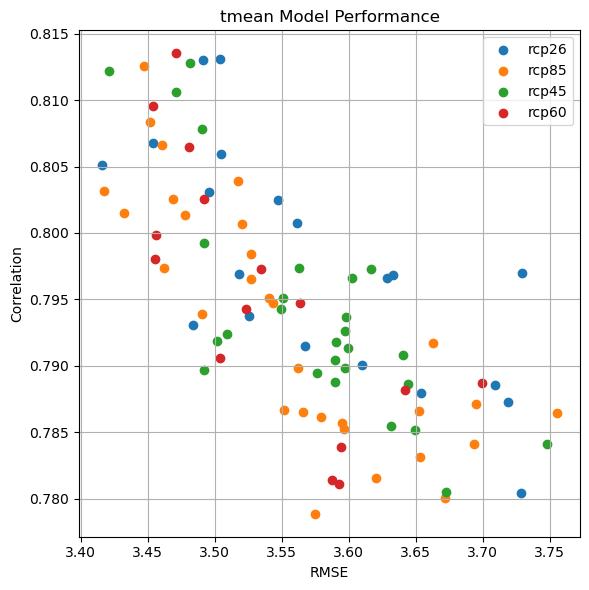

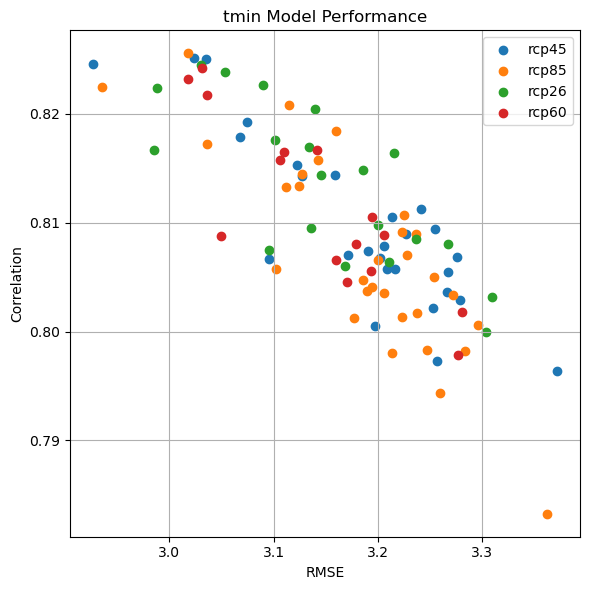

In [21]:
for var in result_df["variable"].unique():
    plt.figure(figsize=(6,6))

    sub = result_df[result_df["variable"] == var]

    for rcp in sub["rcp"].unique():
        s = sub[sub["rcp"] == rcp]

        plt.scatter(s["rmse"], s["corr"], label=rcp)

    plt.xlabel("RMSE")
    plt.ylabel("Correlation")
    plt.title(f"{var} Model Performance")

    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    outpath = output_dir / f"{var} Model Performance.png"
    plt.savefig(outpath, dpi=300, bbox_inches="tight")
    plt.show()

In [39]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

def plot_model_performance_by_rcp_and_modelshape(result_df, variable):
    sub = result_df[result_df["variable"] == variable].copy()

    if sub.empty:
        print(f"[WARN] no data for {variable}")
        return

    # ---- 顏色：RCP ----
    rcp_colors = {
        "rcp26": "tab:green",
        "rcp45": "tab:blue",
        "rcp60": "tab:red",
        "rcp85": "tab:orange",
    }

    # ---- 形狀：model ----
    marker_list = [
        "o", "s", "^", "D", "v", "P", "X", "*", "<", ">", "h", "H",
        "8", "p", "d"
    ]

    models = sorted(sub["model"].unique())
    model_markers = {
        model: marker_list[i % len(marker_list)]
        for i, model in enumerate(models)
    }

    fig, ax = plt.subplots(figsize=(10, 7))

    # 畫點
    for _, row in sub.iterrows():
        ax.scatter(
            row["rmse"],
            row["corr"],
            color=rcp_colors.get(row["rcp"], "gray"),
            marker=model_markers[row["model"]],
            s=90,
            alpha=0.85,
            edgecolor="black",
            linewidth=0.5
        )

    ax.set_title(f"{variable} Model Performance")
    ax.set_xlabel("RMSE")
    ax.set_ylabel("Correlation")
    ax.grid(True, alpha=0.3)

    # ---- 圖例 1：RCP 顏色 ----
    rcp_handles = [
        Line2D(
            [0], [0],
            marker="o",
            color="w",
            label=rcp,
            markerfacecolor=color,
            markeredgecolor="black",
            markersize=9
        )
        for rcp, color in rcp_colors.items()
        if rcp in sub["rcp"].unique()
    ]

    legend1 = ax.legend(
        handles=rcp_handles,
        title="RCP",
        loc="upper right",
        bbox_to_anchor=(1.00, 1.00)
    )
    ax.add_artist(legend1)

    # ---- 圖例 2：model 形狀 ----
    model_handles = [
        Line2D(
            [0], [0],
            marker=model_markers[model],
            color="black",
            linestyle="None",
            label=model,
            markersize=8
        )
        for model in models
    ]

    legend2 = ax.legend(
        handles=model_handles,
        title="Model",
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        ncol=1,
        fontsize=9
    )

    plt.tight_layout()
    outpath = output_dir / f"{variable} Model Performance.png"
    plt.savefig(outpath, dpi=300, bbox_inches="tight")
    plt.show()

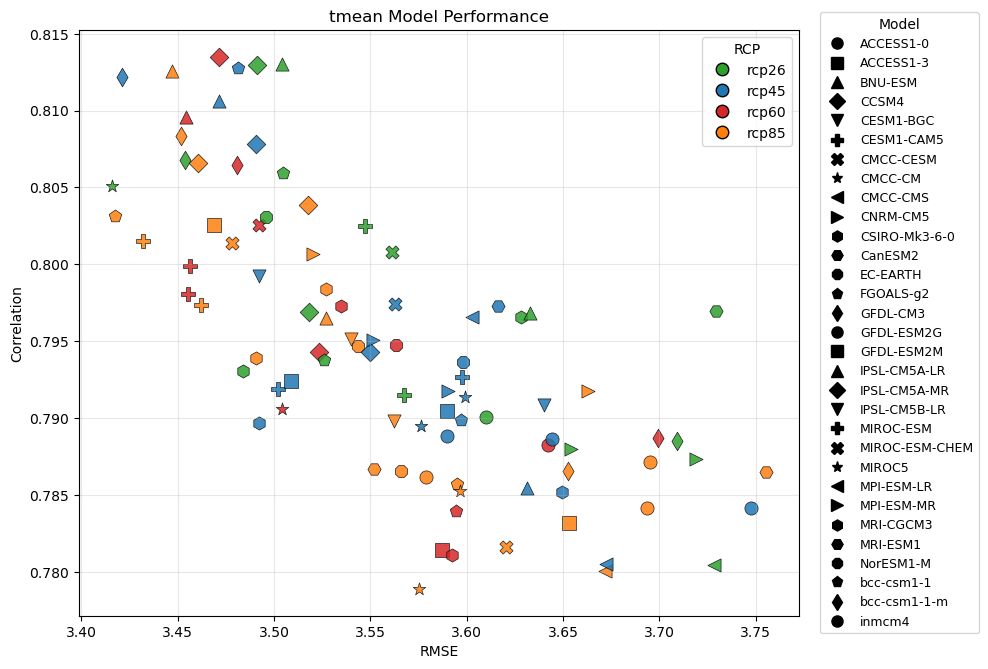

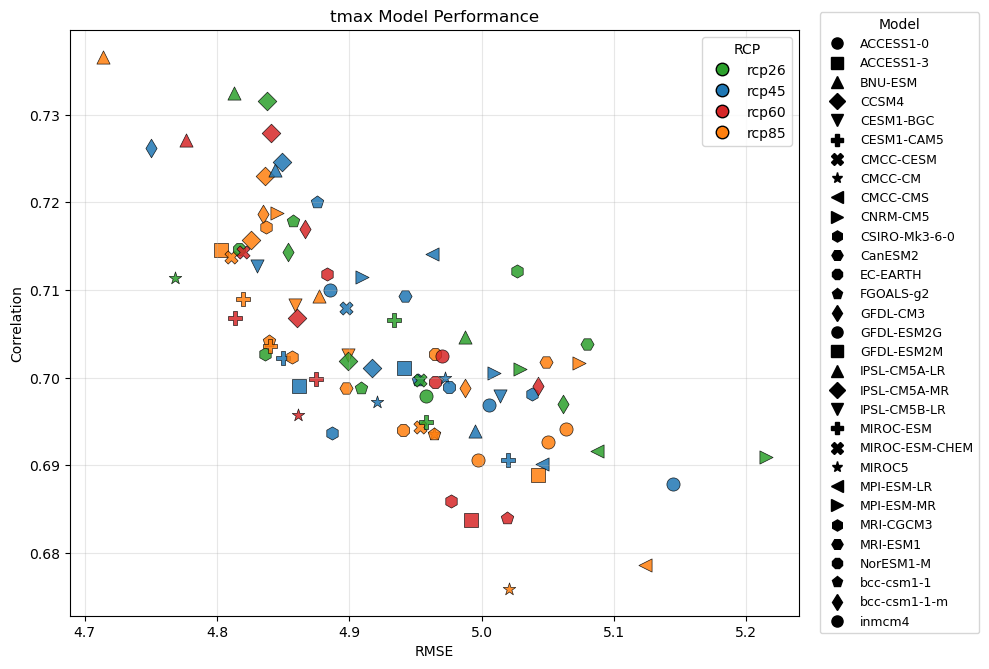

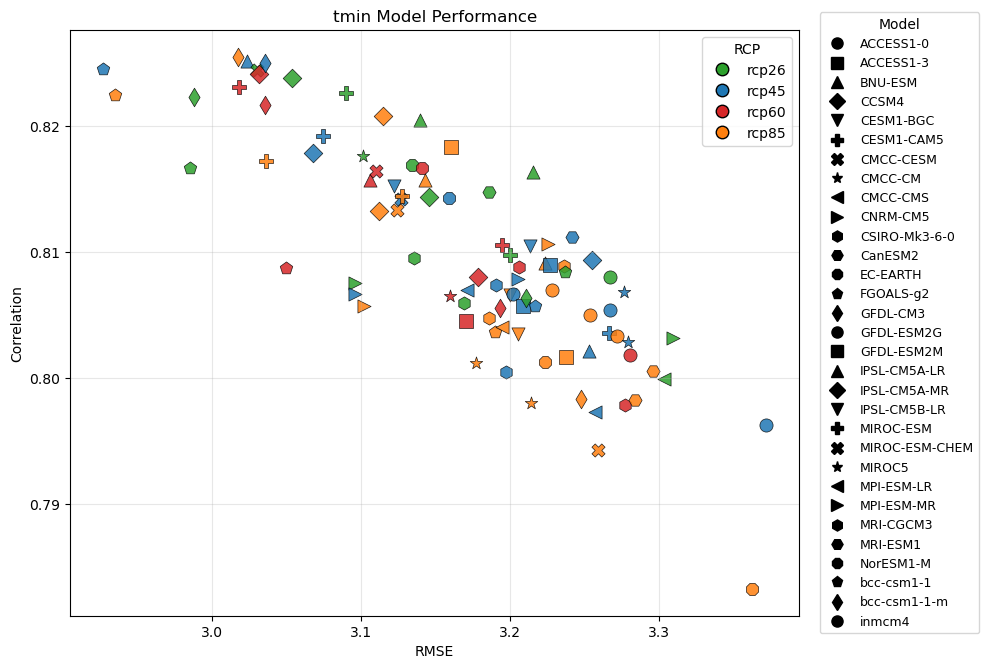

In [40]:
plot_model_performance_by_rcp_and_modelshape(result_df, "tmean")
plot_model_performance_by_rcp_and_modelshape(result_df, "tmax")
plot_model_performance_by_rcp_and_modelshape(result_df, "tmin")

In [ ]:
#修OBS

In [37]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

def plot_top15_models(result_df, variable, top_n=15):
    sub = result_df[result_df["variable"] == variable].copy()

    if sub.empty:
        print(f"[WARN] no data for {variable}")
        return

    # ===== 1. 挑 Top N model（用平均 RMSE）=====
    best_models = (
        sub.groupby("model")["rmse"]
        .mean()
        .sort_values()
        .head(top_n)
        .index.tolist()
    )

    sub = sub[sub["model"].isin(best_models)].copy()

    # ===== 2. 顏色（RCP）=====
    rcp_colors = {
        "rcp26": "tab:green",
        "rcp45": "tab:blue",
        "rcp60": "tab:red",
        "rcp85": "tab:orange",
    }

    # ===== 3. 形狀（model）=====
    marker_list = [
        "o", "s", "^", "D", "v", "P", "X", "*",
        "<", ">", "h", "H", "8", "p", "d"
    ]

    models = sorted(sub["model"].unique())
    model_markers = {
        model: marker_list[i % len(marker_list)]
        for i, model in enumerate(models)
    }

    # ===== 4. 畫圖 =====
    fig, ax = plt.subplots(figsize=(10, 7))

    for _, row in sub.iterrows():
        ax.scatter(
            row["rmse"],
            row["corr"],
            color=rcp_colors.get(row["rcp"], "gray"),
            marker=model_markers[row["model"]],
            s=110,
            alpha=0.9,
            edgecolor="black",
            linewidth=0.6
        )

    ax.set_title(f"{variable} Model Performance (Top {top_n})")
    ax.set_xlabel("RMSE")
    ax.set_ylabel("Correlation")
    ax.grid(True, alpha=0.3)

    # ===== 5. Legend：RCP =====
    rcp_handles = [
        Line2D(
            [0], [0],
            marker="o",
            color="w",
            label=rcp,
            markerfacecolor=color,
            markeredgecolor="black",
            markersize=10
        )
        for rcp, color in rcp_colors.items()
        if rcp in sub["rcp"].unique()
    ]

    legend1 = ax.legend(
        handles=rcp_handles,
        title="RCP",
        loc="upper right"
    )
    ax.add_artist(legend1)

    # ===== 6. Legend：Model（shape）=====
    model_handles = [
        Line2D(
            [0], [0],
            marker=model_markers[model],
            color="black",
            linestyle="None",
            label=model,
            markersize=9
        )
        for model in models
    ]

    ax.legend(
        handles=model_handles,
        title="Model",
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        fontsize=9
    )

    plt.tight_layout()
    outpath = output_dir / f"{variable} Model Performance (Top {top_n}).png"
    plt.savefig(outpath, dpi=300, bbox_inches="tight")
    plt.show()

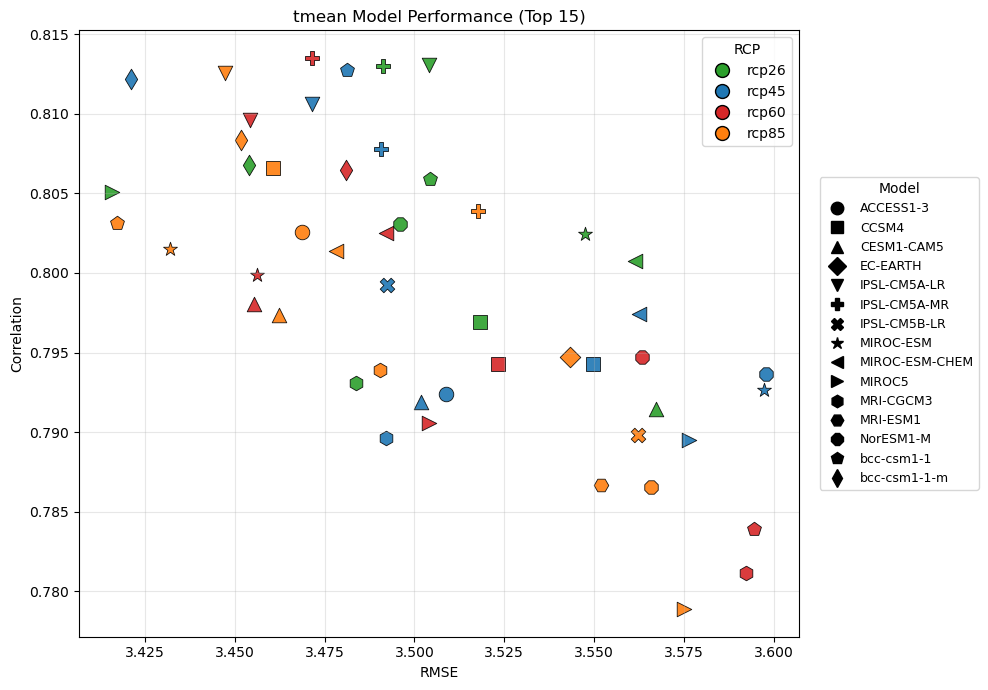

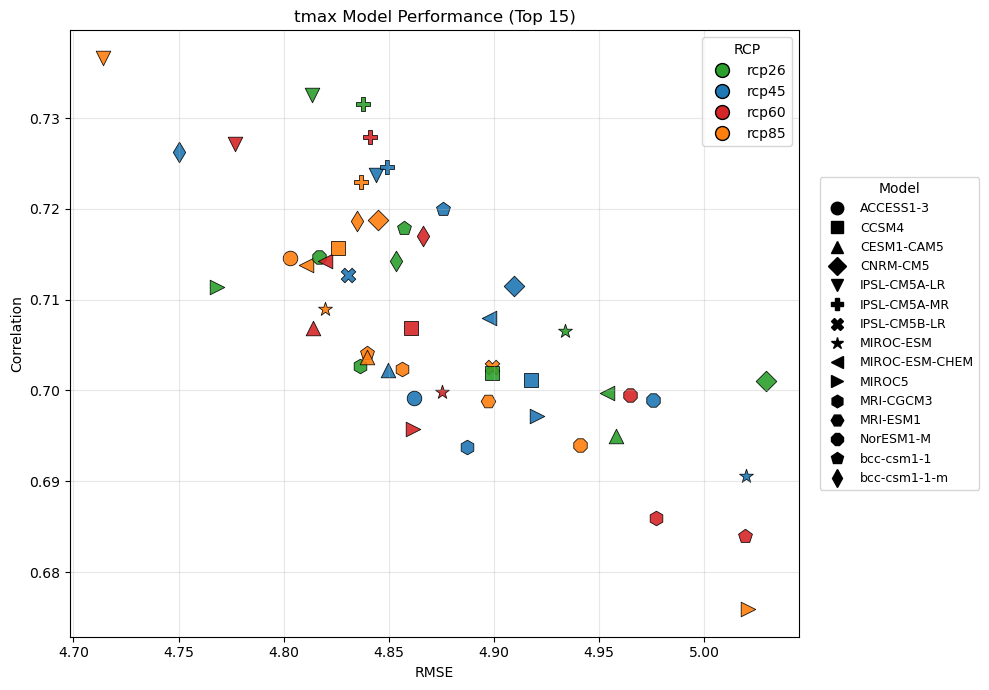

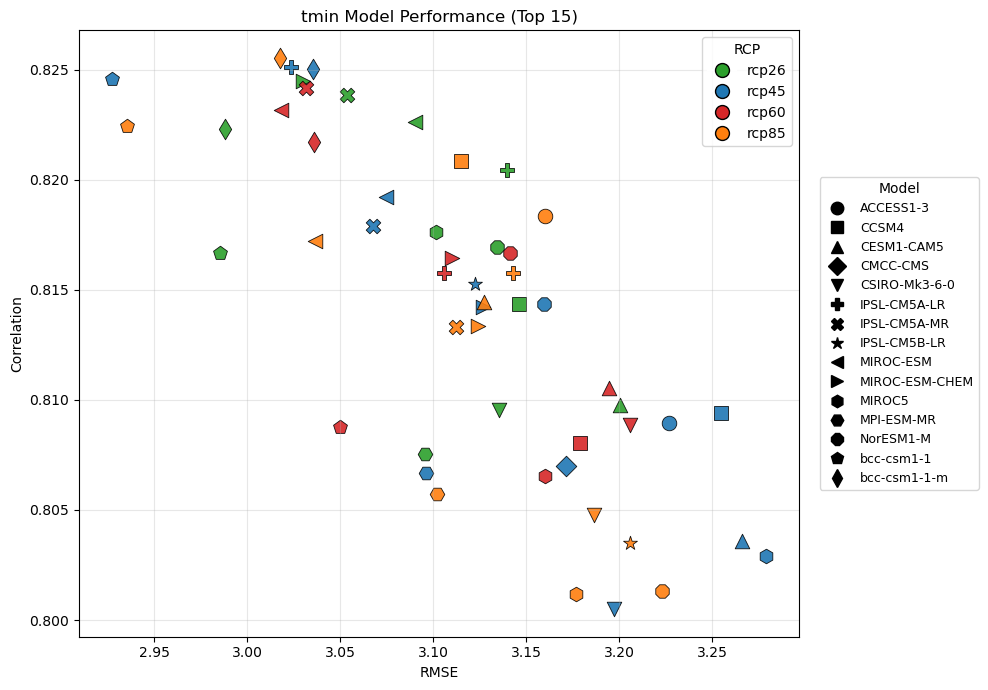

In [38]:
plot_top15_models(result_df, "tmean")
plot_top15_models(result_df, "tmax")
plot_top15_models(result_df, "tmin")

In [41]:
def get_global_top_models(result_df, top_n=15):
    ranking = (
        result_df.groupby("model")
        .agg(
            mean_rmse=("rmse", "mean"),
            mean_corr=("corr", "mean"),
            mean_bias=("bias", "mean")
        )
        .sort_values(["mean_rmse", "mean_corr"], ascending=[True, False])
        .reset_index()
    )

    return ranking.head(top_n)

In [42]:
global_top15 = get_global_top_models(result_df, top_n=15)
print(global_top15.to_string(index=False))

         model  mean_rmse  mean_corr  mean_bias
  bcc-csm1-1-m   3.765803   0.783714   0.499834
  IPSL-CM5A-LR   3.786483   0.786910   0.401247
    bcc-csm1-1   3.790595   0.775365   0.834285
  IPSL-CM5A-MR   3.800059   0.785383   0.490750
     MIROC-ESM   3.825035   0.773720   0.424127
MIROC-ESM-CHEM   3.830612   0.775537   0.499367
     ACCESS1-3   3.838297   0.772668  -0.067684
  IPSL-CM5B-LR   3.851997   0.770539   0.197398
    CESM1-CAM5   3.853081   0.768736   0.025698
         CCSM4   3.854105   0.772538   0.180084
        MIROC5   3.863337   0.764385   0.149977
     MRI-CGCM3   3.874000   0.763565  -0.041652
     NorESM1-M   3.881580   0.769544   0.320881
 CSIRO-Mk3-6-0   3.904108   0.770032   0.512937
     FGOALS-g2   3.909568   0.764373   0.230761


In [43]:
def plot_global_top_models(result_df, variable, global_top_models):
    sub = result_df[
        (result_df["variable"] == variable) &
        (result_df["model"].isin(global_top_models))
    ].copy()

    rcp_colors = {
        "rcp26": "tab:green",
        "rcp45": "tab:blue",
        "rcp60": "tab:red",
        "rcp85": "tab:orange",
    }

    marker_list = ["o", "s", "^", "D", "v", "P", "X", "*", "<", ">", "h", "H", "8", "p", "d"]
    models = sorted(sub["model"].unique())
    model_markers = {model: marker_list[i % len(marker_list)] for i, model in enumerate(models)}

    fig, ax = plt.subplots(figsize=(10, 7))

    for _, row in sub.iterrows():
        ax.scatter(
            row["rmse"], row["corr"],
            color=rcp_colors.get(row["rcp"], "gray"),
            marker=model_markers[row["model"]],
            s=110,
            alpha=0.9,
            edgecolor="black",
            linewidth=0.6
        )

    ax.set_title(f"{variable} Model Performance (Global Top Models)")
    ax.set_xlabel("RMSE")
    ax.set_ylabel("Correlation")
    ax.grid(True, alpha=0.3)

    rcp_handles = [
        Line2D([0], [0], marker="o", color="w", label=rcp,
               markerfacecolor=color, markeredgecolor="black", markersize=10)
        for rcp, color in rcp_colors.items()
        if rcp in sub["rcp"].unique()
    ]
    legend1 = ax.legend(handles=rcp_handles, title="RCP", loc="upper right")
    ax.add_artist(legend1)

    model_handles = [
        Line2D([0], [0], marker=model_markers[model], color="black",
               linestyle="None", label=model, markersize=9)
        for model in models
    ]
    ax.legend(handles=model_handles, title="Model", loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=9)

    plt.tight_layout()
    plt.show()

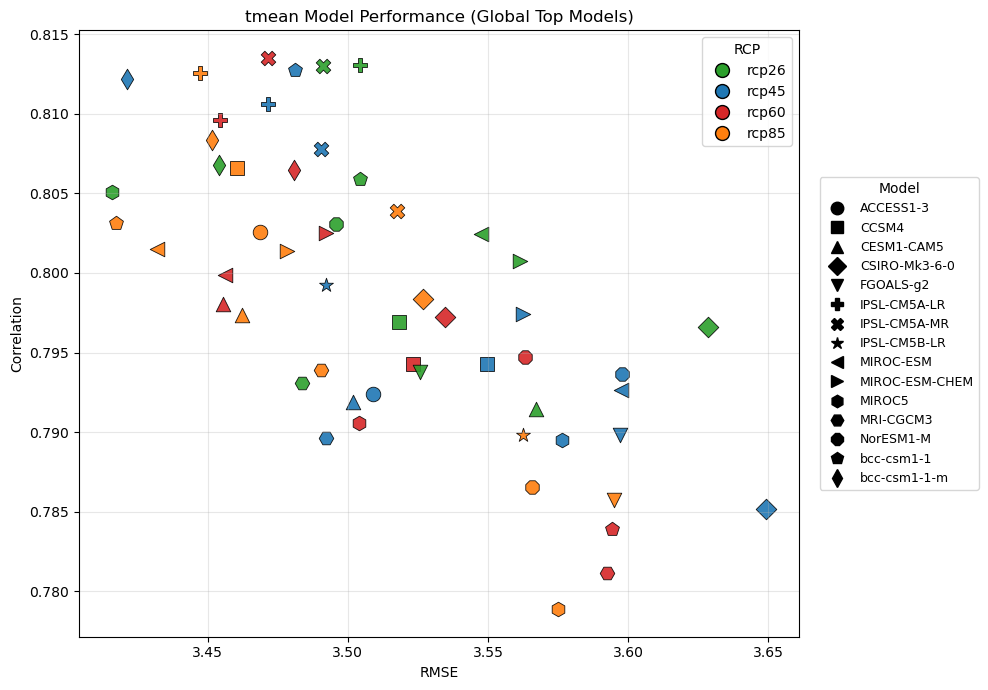

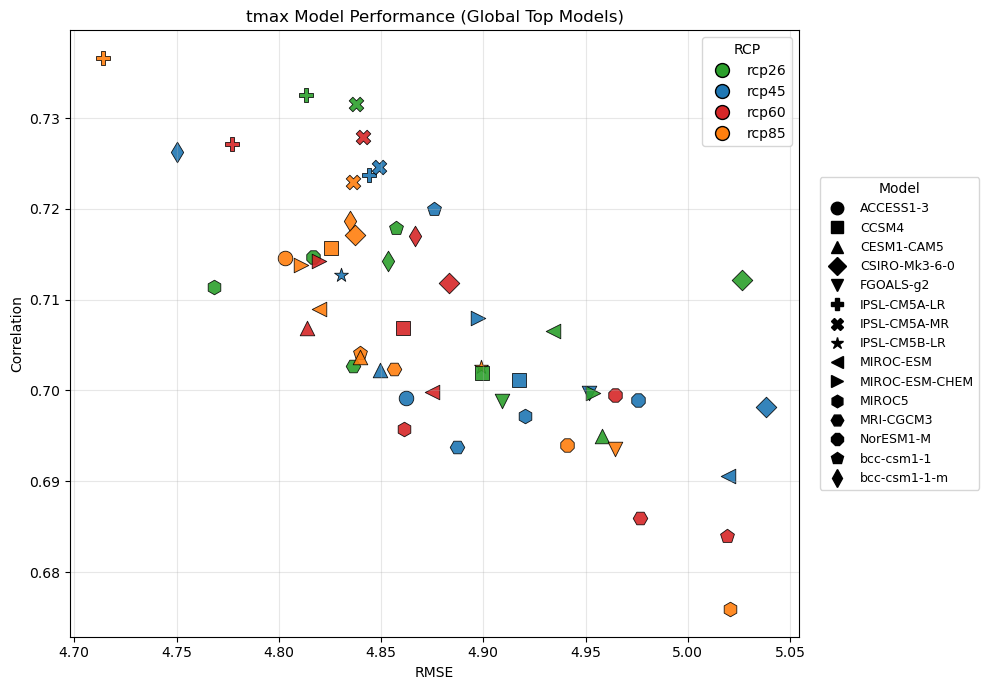

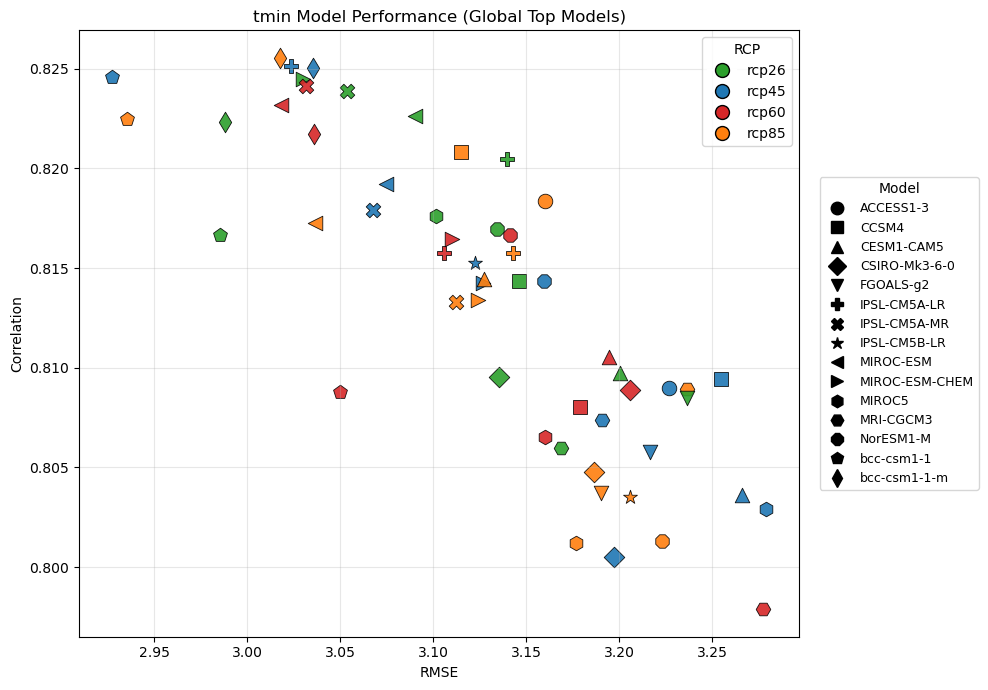

In [44]:
global_top15 = get_global_top_models(result_df, 15)["model"].tolist()

plot_global_top_models(result_df, "tmean", global_top15)
plot_global_top_models(result_df, "tmax", global_top15)
plot_global_top_models(result_df, "tmin", global_top15)

In [47]:
obs_std = {}

for var, model_dict in clean_temp_data.items():
    found = False
    for model_name, rcp_dict in model_dict.items():
        for rcp, info in rcp_dict.items():
            df = info["data"]
            if df is not None and not df.empty:
                obs_std[var] = df["obs"].std()
                found = True
                break
        if found:
            break

print(obs_std)

{'tmean': 5.369549737608782, 'tmax': 6.381881631750082, 'tmin': 5.0031939705778505}


In [48]:
result_df["nrmse"] = result_df.apply(
    lambda row: row["rmse"] / obs_std[row["variable"]],
    axis=1
)


In [49]:
def get_top_models_by_nrmse(result_df, variable, top_n=15):
    sub = result_df[result_df["variable"] == variable].copy()

    ranking = (
        sub.groupby("model")["nrmse"]
        .mean()
        .sort_values()
        .reset_index(name="mean_nrmse")
    )

    return ranking.head(top_n)

In [50]:
print(get_top_models_by_nrmse(result_df, "tmean", 15).to_string(index=False))
print(get_top_models_by_nrmse(result_df, "tmax", 15).to_string(index=False))
print(get_top_models_by_nrmse(result_df, "tmin", 15).to_string(index=False))

         model  mean_nrmse
  bcc-csm1-1-m    0.642859
  IPSL-CM5A-LR    0.646093
     ACCESS1-3    0.649728
  IPSL-CM5A-MR    0.650470
    CESM1-CAM5    0.651210
    bcc-csm1-1    0.651698
     MIROC-ESM    0.653346
         CCSM4    0.654233
     MRI-CGCM3    0.654550
        MIROC5    0.655144
MIROC-ESM-CHEM    0.656205
  IPSL-CM5B-LR    0.656908
      EC-EARTH    0.659909
      MRI-ESM1    0.661496
     NorESM1-M    0.662208
         model  mean_nrmse
  IPSL-CM5A-LR    0.750114
  bcc-csm1-1-m    0.756225
     ACCESS1-3    0.757222
  IPSL-CM5A-MR    0.758575
  IPSL-CM5B-LR    0.762259
    CESM1-CAM5    0.762368
MIROC-ESM-CHEM    0.763161
         CCSM4    0.763995
     MRI-CGCM3    0.766089
        MIROC5    0.766663
      MRI-ESM1    0.767385
    bcc-csm1-1    0.767483
     MIROC-ESM    0.769692
     NorESM1-M    0.771626
      CNRM-CM5    0.772165
         model  mean_nrmse
    bcc-csm1-1    0.594515
  bcc-csm1-1-m    0.603495
     MIROC-ESM    0.610579
  IPSL-CM5A-MR    0.612870
 

In [58]:
def plot_top_models_nrmse(result_df, variable, top_n=15):
    sub = result_df[result_df["variable"] == variable].copy()

    best_models = (
        sub.groupby("model")["nrmse"]
        .mean()
        .sort_values()
        .head(top_n)
        .index.tolist()
    )

    sub = sub[sub["model"].isin(best_models)].copy()

    rcp_colors = {
        "rcp26": "tab:green",
        "rcp45": "tab:blue",
        "rcp60": "tab:red",
        "rcp85": "tab:orange",
    }

    marker_list = ["o", "s", "^", "D", "v", "P", "X", "*", "<", ">", "h", "H", "8", "p", "d"]
    models = sorted(sub["model"].unique())
    model_markers = {model: marker_list[i % len(marker_list)] for i, model in enumerate(models)}

    fig, ax = plt.subplots(figsize=(10, 7))

    for _, row in sub.iterrows():
        ax.scatter(
            row["nrmse"], row["corr"],
            color=rcp_colors.get(row["rcp"], "gray"),
            marker=model_markers[row["model"]],
            s=110,
            edgecolor="black"
        )

    ax.set_title(f"{variable} Model Performance (NRMSE Top {top_n})")
    ax.set_xlabel("NRMSE")
    ax.set_ylabel("Correlation")
    ax.grid(True, alpha=0.3)
    model_handles = [
        Line2D([0], [0], marker=model_markers[model], color="black",
               linestyle="None", label=model, markersize=9)
        for model in models
    ]    
    ax.legend(handles=model_handles, title="Model", loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=9)

    plt.tight_layout()
    outpath = output_dir / f"{variable} Model Performance (NRMSE Top {top_n}).png"
    plt.savefig(outpath, dpi=300, bbox_inches="tight")
    plt.show()

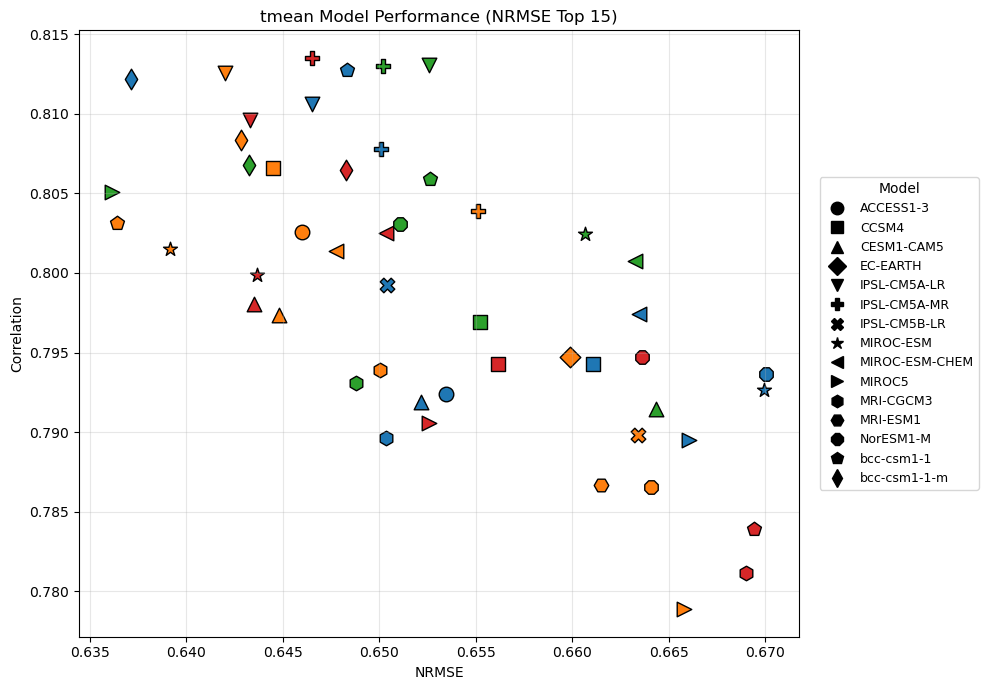

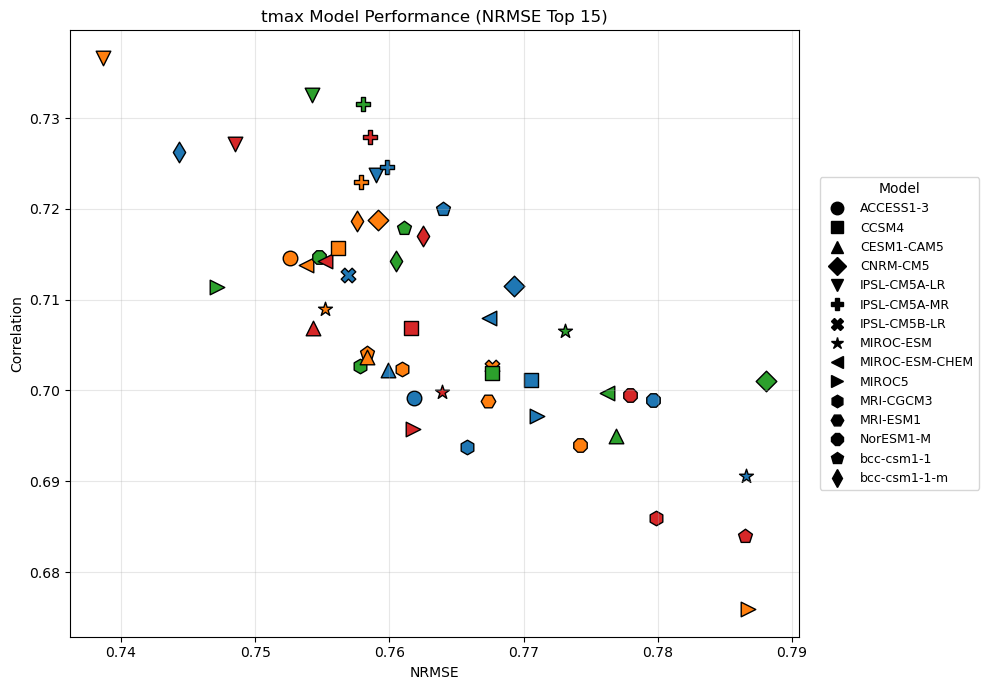

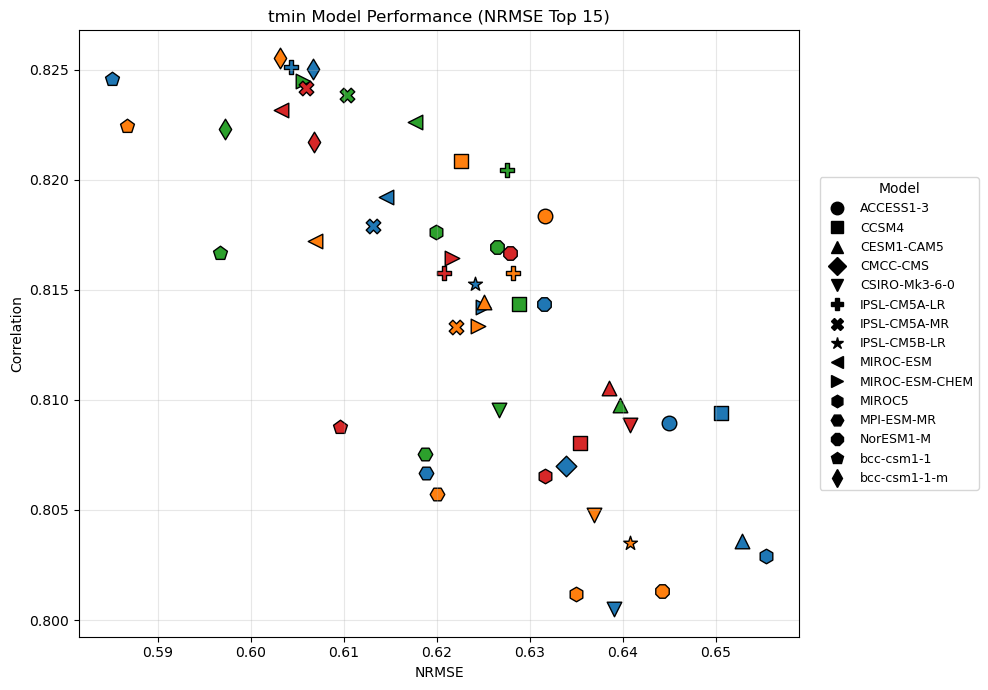

In [59]:
plot_top_models_nrmse(result_df, "tmean", 15)
plot_top_models_nrmse(result_df, "tmax",15)
plot_top_models_nrmse(result_df, "tmin",15)